# Noise-Free CW: Distance Likelihood Landscape

**Purpose:** Demonstrate that, in the absence of noise, the phase-connected CW likelihood
is essentially degenerate in pulsar distance for a single CW source, and that adding
multiple CW sources breaks this degeneracy.

By injecting pure CW signals (no white noise, no red noise, no GWB) and evaluating
the likelihood with white-noise-only noise model, we isolate the effect of pulsar
distance on the CW model fit without any noise-driven scatter.

**Key prediction:**
- Single CW: all distance modes have essentially the same likelihood (Δln L ≈ 0)
- Multiple CWs: only the true distance satisfies all CW phase constraints simultaneously


In [1]:
import sys, importlib
sys.path.insert(0, ".")
import cw_helpers
importlib.reload(cw_helpers)
from cw_helpers import *
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


/home/mattm/miniforge3/envs/discotech/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename


## 1. Load pulsars

In [2]:
Npulsars = 10
_, disco_psrs = load_pulsars(Npulsars)
print(f"Loaded {Npulsars} pulsars (discovery only, no enterprise needed for noise-free injection)")
for p in disco_psrs:
    print(f"  {p.name:16s}  pdist = {p.pdist[0]:.4f} kpc")


FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

## 2. Single CW: noise-free injection

Inject a single CW source and scan each pulsar's distance. We expect the likelihood
to be periodic in distance with nearly uniform peak heights — each mode corresponds
to a valid phase assignment for the pulsar term and is equally good.


In [3]:
cw_single = [{
    "cos_gwtheta": 0.3,
    "gwphi": 2.5,
    "cos_inc": -0.2,
    "log10_mc": 9.0,
    "log10_fgw": -8.0,
    "log10_h": -13.5,
    "phase0": 1.0,
    "psi": 0.7,
}]

rmap_single, true_dists = inject_noisefree_cw(disco_psrs, cw_single)
logl_fn_1, pkeys_1, bvals_1 = build_noisefree_likelihood(disco_psrs, rmap_single, 1, cw_single)

ll_truth_1 = float(logl_fn_1(bvals_1))
print(f"ln L(truth) = {ll_truth_1:.4f}")
print()

# Show CW signal RMS per pulsar
for psr in disco_psrs:
    rms = np.std(rmap_single[psr.name]) * 1e9
    dL = compute_mode_spacing(0.3, 2.5, -8.0, psr.pos)
    print(f"  {psr.name:16s}: CW rms = {rms:8.2f} ns, dL = {dL:.6f} kpc")


ln L(truth) = 38880.2408

  B1855+09        : CW rms =   110.75 ns, dL = 0.003007 kpc
  B1937+21        : CW rms =    94.32 ns, dL = 0.002931 kpc
  B1953+29        : CW rms =    57.97 ns, dL = 0.002506 kpc
  J0023+0923      : CW rms =    83.82 ns, dL = 0.002736 kpc
  J0030+0451      : CW rms =    11.50 ns, dL = 0.002815 kpc
  J0125-2327      : CW rms =   104.46 ns, dL = 0.002336 kpc
  J0340+4130      : CW rms =   411.19 ns, dL = 0.000797 kpc
  J0406+3039      : CW rms =   359.52 ns, dL = 0.000766 kpc
  J0437-4715      : CW rms =   251.27 ns, dL = 0.001016 kpc
  J0509+0856      : CW rms =   172.63 ns, dL = 0.000681 kpc


In [4]:
# Scan each pulsar's distance
single_cw_scans = {}

for psr in disco_psrs:
    dkey = f"{psr.name}_cw_p_dist"
    if dkey not in pkeys_1:
        continue

    true_d = psr.pdist[0]
    dL = compute_mode_spacing(0.3, 2.5, -8.0, psr.pos)

    # Scan over 10 mode spacings
    scan_half = 10 * dL
    scan_min = max(0.01, true_d - scan_half)
    scan_max = true_d + scan_half

    scan_d, scan_ll = scan_pulsar_distance(
        logl_fn_1, bvals_1, pkeys_1, dkey,
        scan_min, scan_max, n_points=4000,
    )

    single_cw_scans[psr.name] = {
        "scan_d": scan_d,
        "scan_ll": scan_ll,
        "true_dist": true_d,
        "dL": dL,
    }

print("Distance scans complete for all pulsars")


Distance scans complete for all pulsars


### Single CW distance landscape

Each panel shows $\Delta \ln L$ = ln L(d) - ln L(truth) for one pulsar.
The red dashed line marks the injected (true) distance.

If all peaks are at the same height (Δln L ≈ 0), the distance is uninformative
for a single CW — any mode is as good as any other.


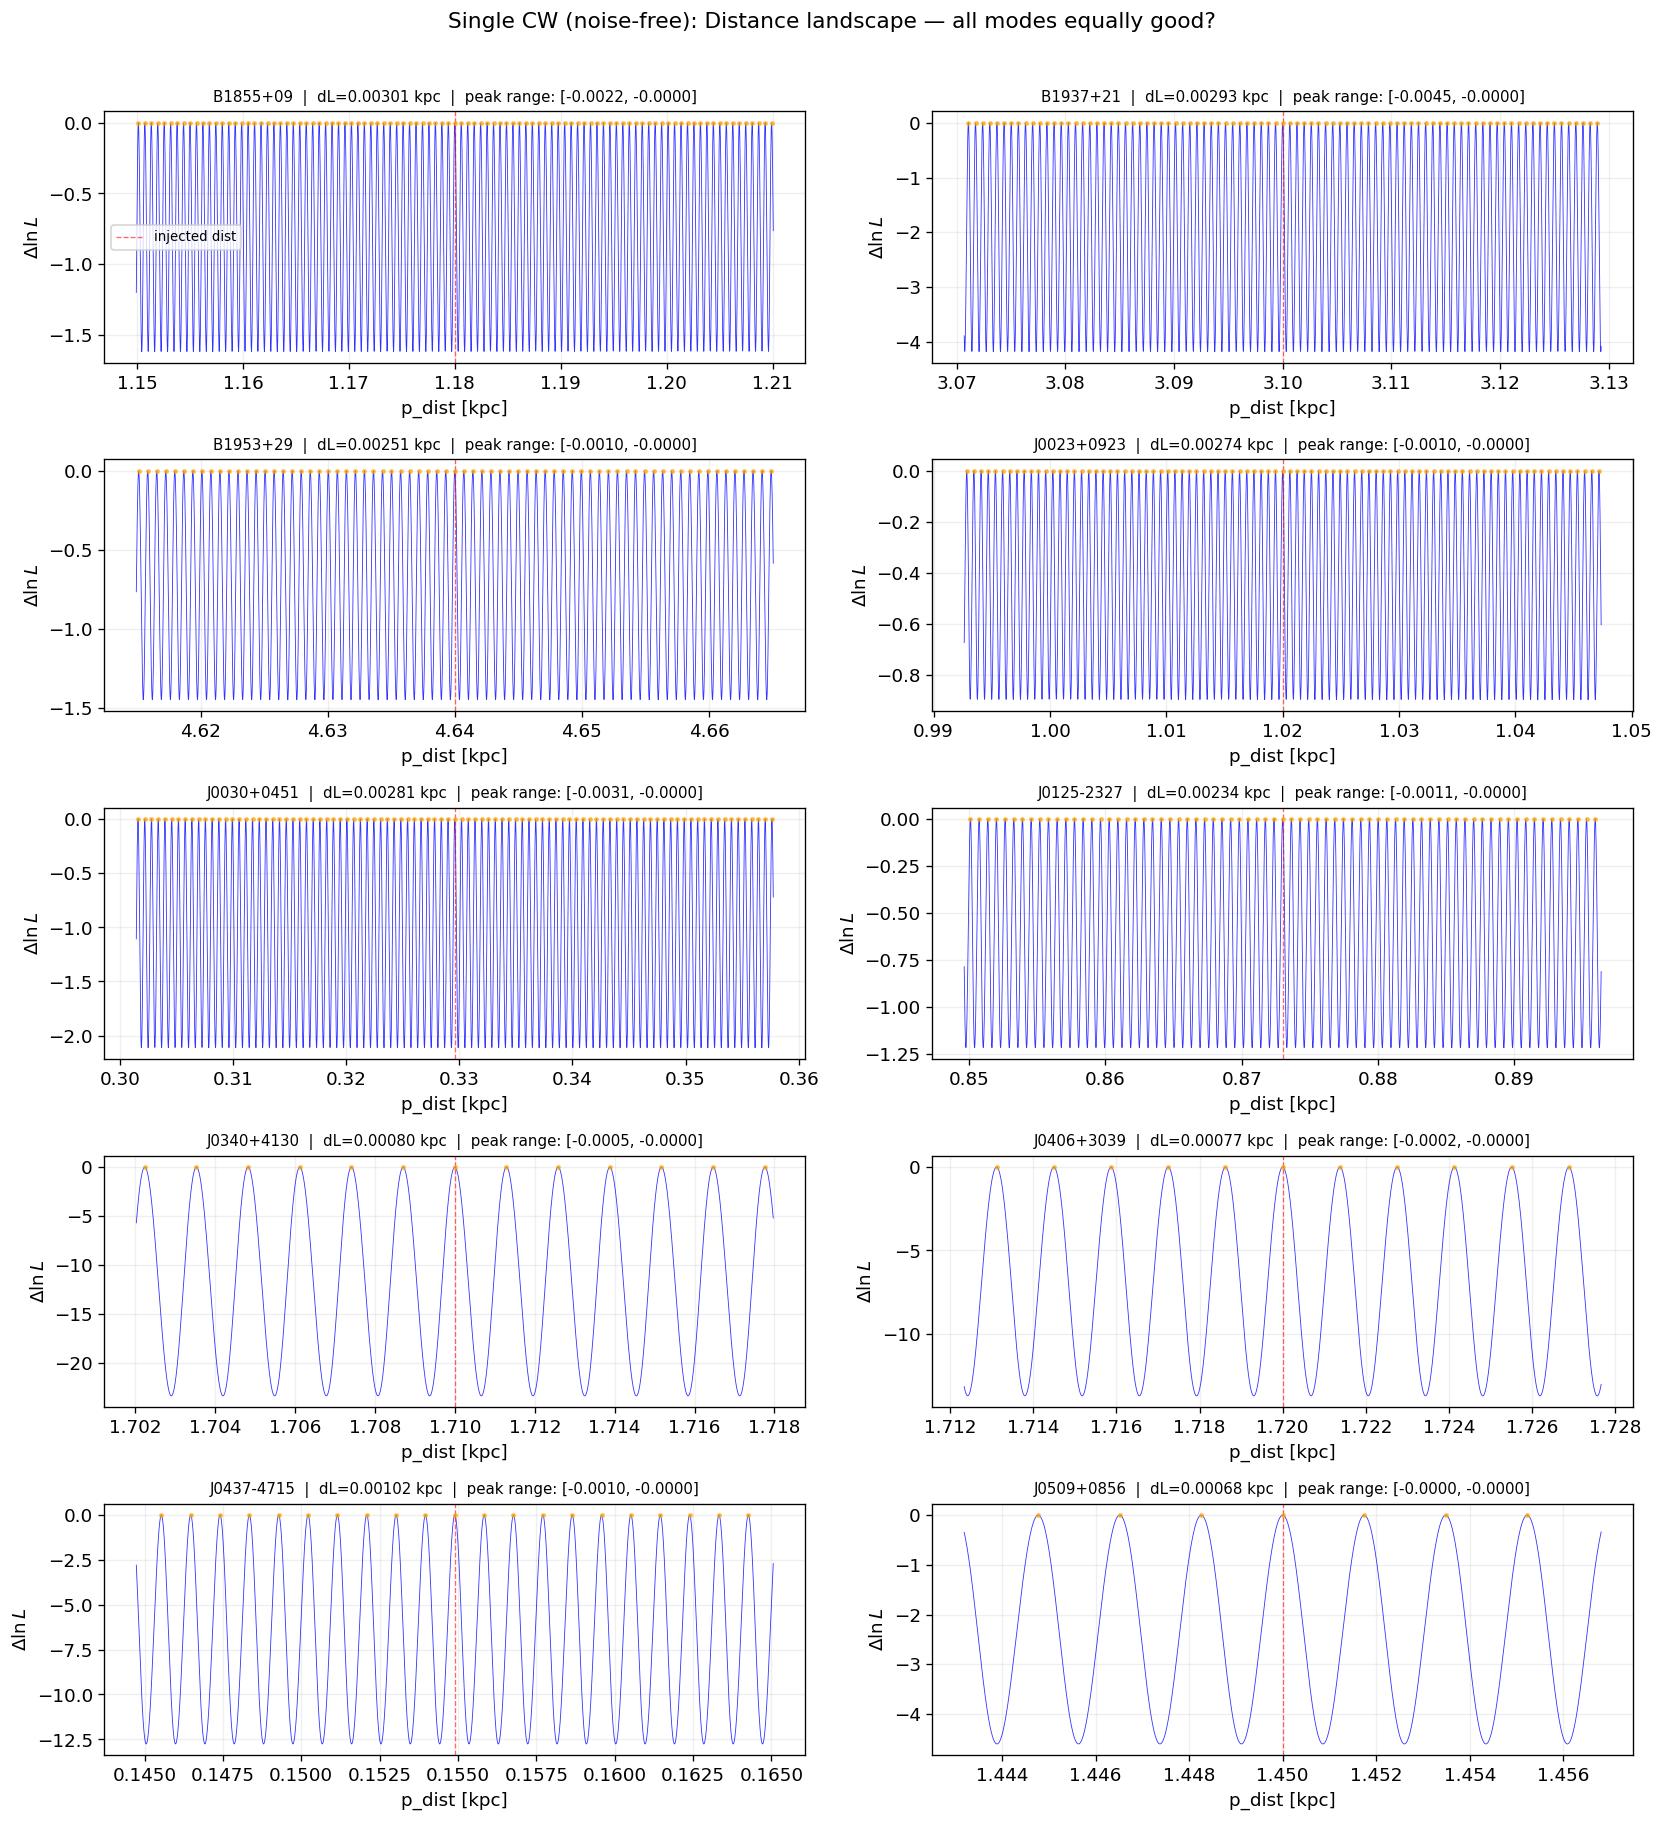

In [5]:
ncols = 2
nrows = (len(single_cw_scans) + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows))
axes = axes.flatten()

for i, (pname, sc) in enumerate(sorted(single_cw_scans.items())):
    ax = axes[i]
    rel_ll = sc["scan_ll"] - ll_truth_1

    ax.plot(sc["scan_d"], rel_ll, "b-", lw=0.5, alpha=0.8)
    ax.axvline(sc["true_dist"], color="red", ls="--", lw=0.8, alpha=0.6, label="injected dist")

    # Find and mark peaks
    prom = max(0.01, 0.01 * (np.max(rel_ll) - np.min(rel_ll)))
    peaks, _ = find_peaks(sc["scan_ll"], prominence=prom, distance=3)
    if len(peaks) > 0:
        peak_heights = rel_ll[peaks]
        ax.plot(sc["scan_d"][peaks], peak_heights, "o", color="orange", ms=2, alpha=0.6)

        # Annotate peak height range
        ax.set_title(
            f"{pname}  |  dL={sc['dL']:.5f} kpc  |  "
            f"peak range: [{np.min(peak_heights):.4f}, {np.max(peak_heights):.4f}]",
            fontsize=9,
        )
    else:
        ax.set_title(f"{pname}  |  dL={sc['dL']:.5f} kpc", fontsize=9)

    ax.set_xlabel("p_dist [kpc]")
    ax.set_ylabel(r"$\Delta \ln L$")
    ax.grid(True, alpha=0.2)
    if i == 0:
        ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Single CW (noise-free): Distance landscape — all modes equally good?",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()


### Peak height statistics (single CW)

For each pulsar, collect all peak heights and show their range.
If the range is ≈ 0, the distance is uninformative.


In [6]:
print(f"{'Pulsar':16s} | {'N peaks':>8s} | {'Peak max':>10s} | {'Peak min':>10s} | {'Range':>10s} | {'dL (kpc)':>10s}")
print("-" * 75)

for pname in sorted(single_cw_scans.keys()):
    sc = single_cw_scans[pname]
    rel_ll = sc["scan_ll"] - ll_truth_1
    prom = max(0.01, 0.01 * (np.max(rel_ll) - np.min(rel_ll)))
    peaks, _ = find_peaks(sc["scan_ll"], prominence=prom, distance=3)

    if len(peaks) > 0:
        ph = rel_ll[peaks]
        print(f"{pname:16s} | {len(peaks):8d} | {np.max(ph):10.4f} | {np.min(ph):10.4f} | "
              f"{np.max(ph)-np.min(ph):10.4f} | {sc['dL']:10.6f}")
    else:
        print(f"{pname:16s} | {'0':>8s} | {'N/A':>10s} | {'N/A':>10s} | {'N/A':>10s} | {sc['dL']:10.6f}")


Pulsar           |  N peaks |   Peak max |   Peak min |      Range |   dL (kpc)
---------------------------------------------------------------------------
B1855+09         |       99 |    -0.0000 |    -0.0022 |     0.0022 |   0.003007
B1937+21         |       89 |    -0.0000 |    -0.0045 |     0.0045 |   0.002931
B1953+29         |       71 |    -0.0000 |    -0.0010 |     0.0010 |   0.002506
J0023+0923       |       89 |    -0.0000 |    -0.0010 |     0.0010 |   0.002736
J0030+0451       |       95 |    -0.0000 |    -0.0031 |     0.0031 |   0.002815
J0125-2327       |       73 |    -0.0000 |    -0.0011 |     0.0011 |   0.002336
J0340+4130       |       13 |    -0.0000 |    -0.0005 |     0.0005 |   0.000797
J0406+3039       |       11 |    -0.0000 |    -0.0002 |     0.0002 |   0.000766
J0437-4715       |       21 |    -0.0000 |    -0.0010 |     0.0010 |   0.001016
J0509+0856       |        7 |    -0.0000 |    -0.0000 |     0.0000 |   0.000681


## 3. Multiple CWs: noise-free injection

Now inject multiple CW sources (N=2, 4, 7, 10) with a single shared distance per pulsar.
Each CW creates its own periodic distance modulation with a different spacing $\Delta L$.
The true distance is the only point where ALL CW phases are simultaneously correct.


In [7]:
rng = np.random.default_rng(42)

def make_cw_params(n_sources, rng, scenario="well_separated"):
    # Generate n_sources CW parameter dicts.
    sources = []
    for i in range(n_sources):
        if scenario == "close_freq":
            log10_fgw = -8.0 + rng.uniform(-0.1, 0.1)
            cos_gwtheta = rng.uniform(-1, 1)
            gwphi = rng.uniform(0, 2 * np.pi)
        elif scenario == "close_sky":
            log10_fgw = rng.uniform(-8.5, -7.5)
            cos_gwtheta = np.clip(0.3 + rng.uniform(-0.05, 0.05), -1, 1)
            gwphi = 2.5 + rng.uniform(-0.055, 0.055)
        else:  # well_separated
            log10_fgw = rng.uniform(-8.5, -7.5)
            cos_gwtheta = rng.uniform(-1, 1)
            gwphi = rng.uniform(0, 2 * np.pi)

        sources.append({
            "cos_gwtheta": cos_gwtheta,
            "gwphi": gwphi,
            "cos_inc": rng.uniform(-1, 1),
            "log10_mc": 9.0,
            "log10_fgw": log10_fgw,
            "log10_h": -13.5,
            "phase0": rng.uniform(0, 2 * np.pi),
            "psi": rng.uniform(0, np.pi),
        })
    return sources


In [8]:
ncw_values = [1, 2, 4, 7, 10, 25, 50, 100, 250, 500]
test_psr = disco_psrs[0]  # Use first pulsar as representative
test_psr_name = test_psr.name
scenario = "well_separated"

multi_cw_results = {}

for ncw in ncw_values:
    print(f"\n--- N_CW = {ncw} ---")

    rng_local = np.random.default_rng(42)
    cw_params = make_cw_params(ncw, rng_local, scenario=scenario)

    # Inject noise-free
    rmap, _ = inject_noisefree_cw(disco_psrs, cw_params)
    logl_fn, pkeys, bvals = build_noisefree_likelihood(disco_psrs, rmap, ncw, cw_params)

    ll_truth = float(logl_fn(bvals))
    print(f"  ln L(truth) = {ll_truth:.2f}")

    # Compute mode spacings for all CWs at test pulsar
    all_dL = []
    for cw_p in cw_params:
        dL = compute_mode_spacing(cw_p["cos_gwtheta"], cw_p["gwphi"],
                                  cw_p["log10_fgw"], test_psr.pos)
        all_dL.append(dL)
        print(f"  CW: f_gw=10^{cw_p['log10_fgw']:.2f} Hz, dL={dL:.6f} kpc")

    min_dL = min(all_dL)
    max_dL = max(all_dL)

    # Scan test pulsar distance
    dkey = f"{test_psr_name}_cw_p_dist"
    true_d = test_psr.pdist[0]
    scan_half = 10 * max_dL
    scan_min = max(0.01, true_d - scan_half)
    scan_max = true_d + scan_half

    scan_d, scan_ll = scan_pulsar_distance(
        logl_fn, bvals, pkeys, dkey,
        scan_min, scan_max, n_points=5000,
    )

    # Peak analysis
    analysis = analyze_peaks(scan_d, scan_ll, true_d, mode_spacing=min_dL)

    multi_cw_results[ncw] = {
        "scan_d": scan_d,
        "scan_ll": scan_ll,
        "true_dist": true_d,
        "all_dL": all_dL,
        "min_dL": min_dL,
        "max_dL": max_dL,
        "ll_truth": ll_truth,
        "analysis": analysis,
    }

    delta = analysis["delta_lnL_truth_vs_best_wrong"]
    print(f"  Peaks found: {analysis['n_peaks']}")
    print(f"  Delta ln L (truth - best wrong): {delta:.4f}" if not np.isnan(delta) else
          f"  Delta ln L: N/A")

    # Joint: best wrong mode within EM prior for each pulsar
    joint = compute_joint_best_wrong_in_prior(
        logl_fn, bvals, pkeys,
        disco_psrs, disco_psrs, cw_params, n_sigma=3.0,
    )
    multi_cw_results[ncw]["ll_wrong_joint"] = joint["ll_best_wrong"]
    multi_cw_results[ncw]["delta_joint"] = joint["delta_lnL"]
    print(f"  Joint Delta ln L (best wrong in EM prior): {joint['delta_lnL']:.4f}")

    jax.clear_caches()

print("\nDone!")



--- N_CW = 1 ---


  ln L(truth) = 38880.24
  CW: f_gw=10^-7.73 Hz, dL=0.000278 kpc
  Peaks found: 1
  Delta ln L: N/A
  Joint Delta ln L (best wrong in EM prior): 0.0075

--- N_CW = 2 ---
  ln L(truth) = 38880.24
  CW: f_gw=10^-7.73 Hz, dL=0.000278 kpc
  CW: f_gw=10^-7.74 Hz, dL=0.000804 kpc
  Peaks found: 8
  Delta ln L (truth - best wrong): 0.0894
  Joint Delta ln L (best wrong in EM prior): 1.2772

--- N_CW = 4 ---
  ln L(truth) = 38880.24
  CW: f_gw=10^-7.73 Hz, dL=0.000278 kpc
  CW: f_gw=10^-7.74 Hz, dL=0.000804 kpc
  CW: f_gw=10^-7.86 Hz, dL=0.001021 kpc
  CW: f_gw=10^-7.67 Hz, dL=0.000232 kpc
  Peaks found: 35
  Delta ln L (truth - best wrong): 2.8724
  Joint Delta ln L (best wrong in EM prior): 6.8541

--- N_CW = 7 ---
  ln L(truth) = 38880.24
  CW: f_gw=10^-7.73 Hz, dL=0.000278 kpc
  CW: f_gw=10^-7.74 Hz, dL=0.000804 kpc
  CW: f_gw=10^-7.86 Hz, dL=0.001021 kpc
  CW: f_gw=10^-7.67 Hz, dL=0.000232 kpc
  CW: f_gw=10^-7.72 Hz, dL=0.000919 kpc
  CW: f_gw=10^-7.76 Hz, dL=0.000679 kpc
  CW: f_gw=10^-8

E0414 15:54:01.880585 3224969 slow_operation_alarm.cc:73] 
********************************
[Compiling module input_reduce_fusion.4 for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
E0414 15:55:22.029885 3224949 slow_operation_alarm.cc:140] The operation took 3m20.149360727s

********************************
[Compiling module input_reduce_fusion.4 for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


  Peaks found: 1118
  Delta ln L (truth - best wrong): 0.0000
  Joint Delta ln L (best wrong in EM prior): 25370.8783

Done!


### Distance landscape comparison

As N_CW increases, the truth peak should progressively dominate the landscape.
The wrong-mode peaks should drop in height because the single distance cannot
simultaneously satisfy all CW phase constraints.


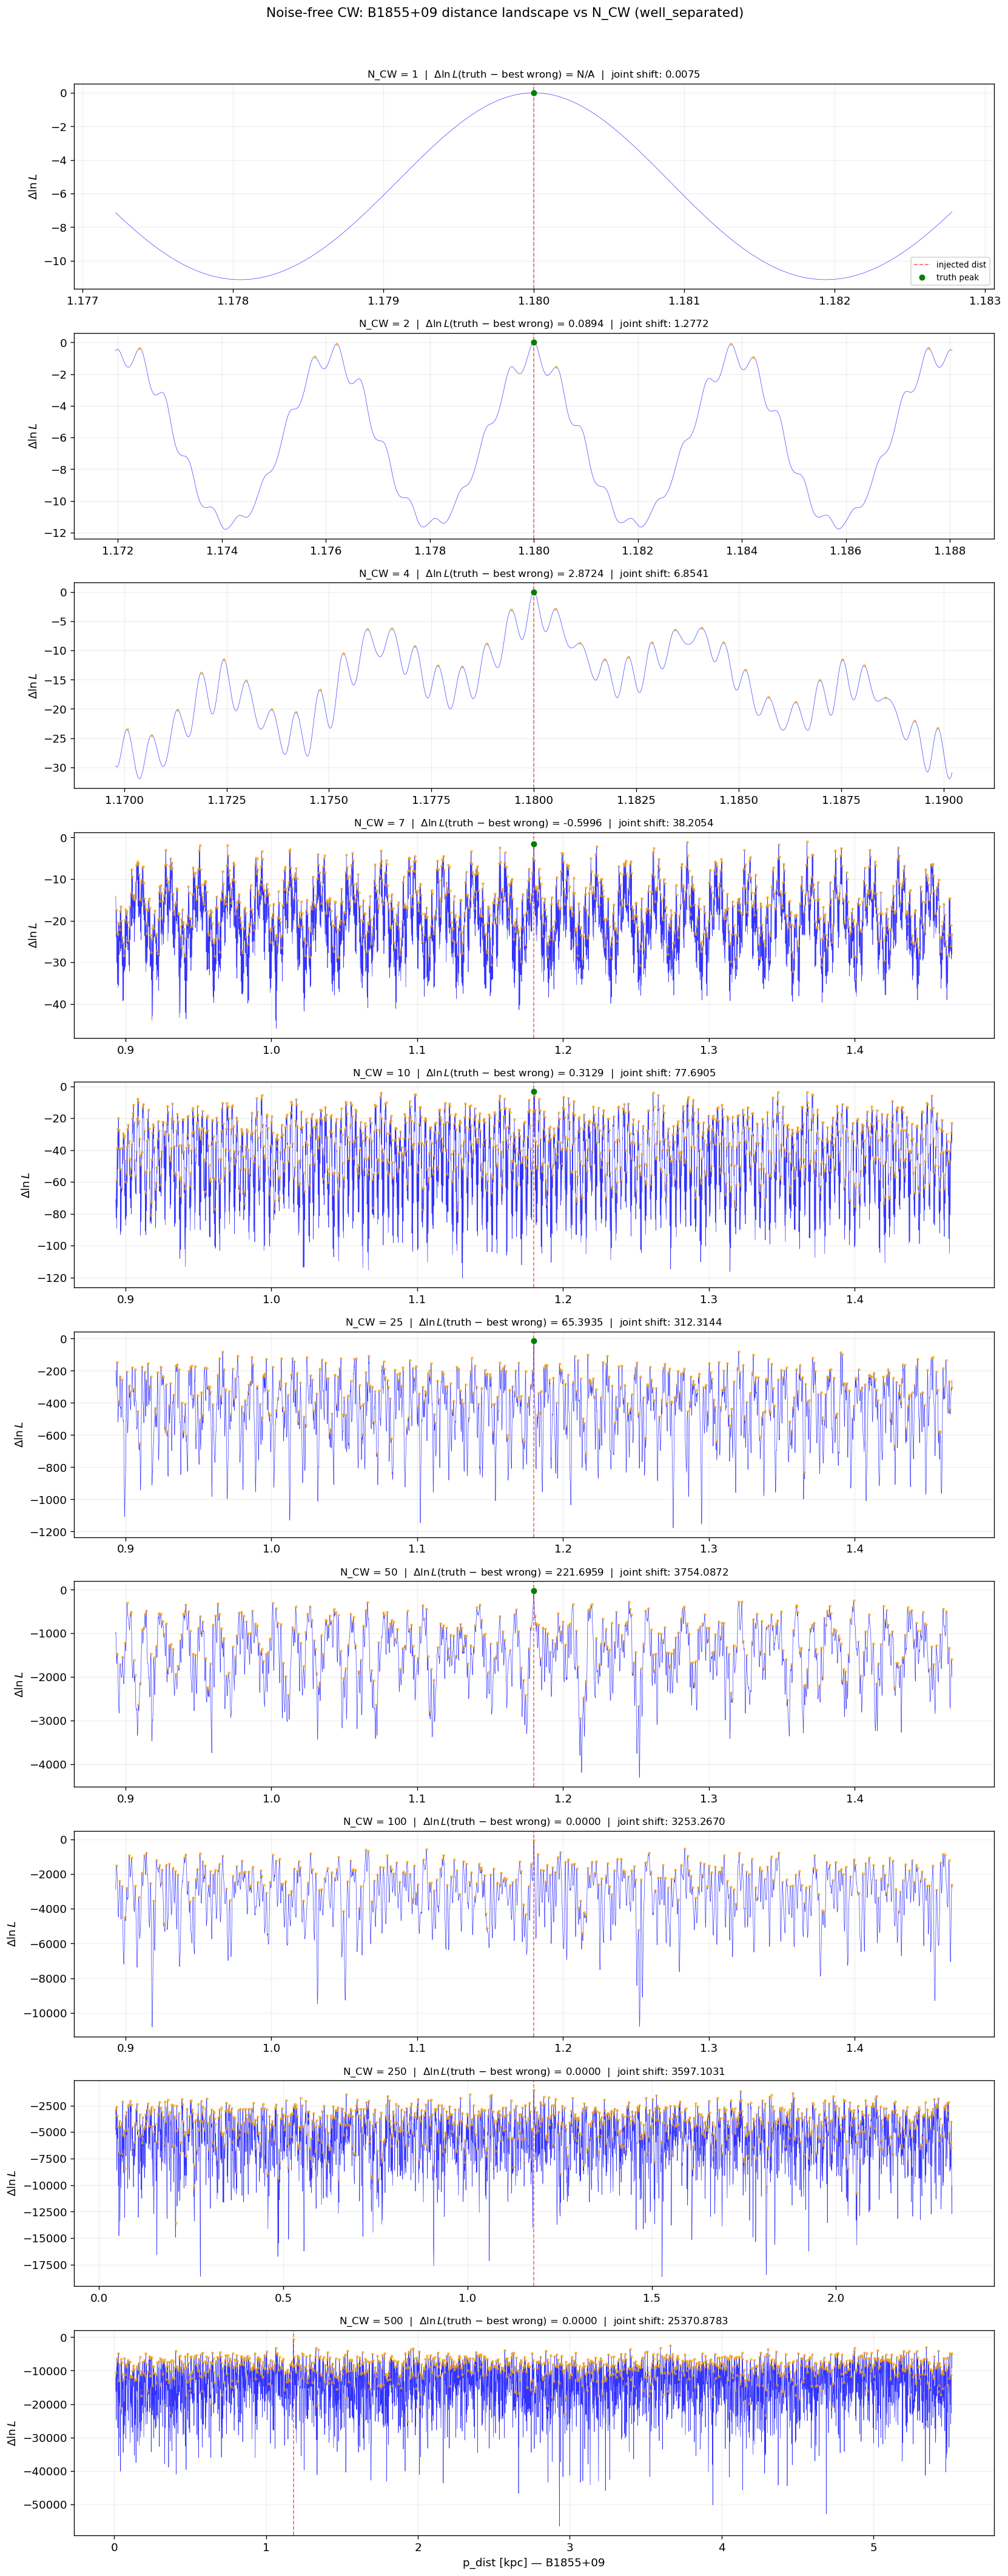

In [9]:
fig, axes = plt.subplots(len(ncw_values), 1, figsize=(14, 3.5 * len(ncw_values)))

for ax_idx, ncw in enumerate(ncw_values):
    ax = axes[ax_idx]
    r = multi_cw_results[ncw]
    scan_d, scan_ll = r["scan_d"], r["scan_ll"]
    baseline = r["ll_truth"]
    rel_ll = scan_ll - baseline

    ax.plot(scan_d, rel_ll, "b-", lw=0.4, alpha=0.8)
    ax.axvline(r["true_dist"], color="red", ls="--", lw=1, alpha=0.6, label="injected dist")

    # Mark peaks
    a = r["analysis"]
    if len(a["peak_distances"]) > 0:
        truth_mask = np.abs(a["peak_distances"] - r["true_dist"]) < 0.3 * r["min_dL"]
        wrong_mask = ~truth_mask

        if np.any(wrong_mask):
            wrong_rel = a["peak_heights"][wrong_mask] - baseline
            ax.plot(a["peak_distances"][wrong_mask], wrong_rel,
                    "o", color="orange", ms=2, alpha=0.5, label="wrong peaks")
        if np.any(truth_mask):
            truth_rel = a["peak_heights"][truth_mask] - baseline
            ax.plot(a["peak_distances"][truth_mask], truth_rel,
                    "o", color="green", ms=5, label="truth peak")

    delta = a["delta_lnL_truth_vs_best_wrong"]
    delta_str = f"{delta:.4f}" if not np.isnan(delta) else "N/A"
    ax.set_ylabel(r"$\Delta \ln L$")
    ax.set_title(f"N_CW = {ncw}  |  "
                 r"$\Delta \ln L$(truth $-$ best wrong) = " + delta_str +
                 f"  |  joint shift: {r['delta_joint']:.4f}",
                 fontsize=10)
    ax.grid(True, alpha=0.2)
    if ax_idx == 0:
        ax.legend(fontsize=8, loc="lower right")

axes[-1].set_xlabel(f"p_dist [kpc] — {test_psr_name}")
fig.suptitle(f"Noise-free CW: {test_psr_name} distance landscape vs N_CW ({scenario})",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()


### Summary plot: Δln L vs N_CW

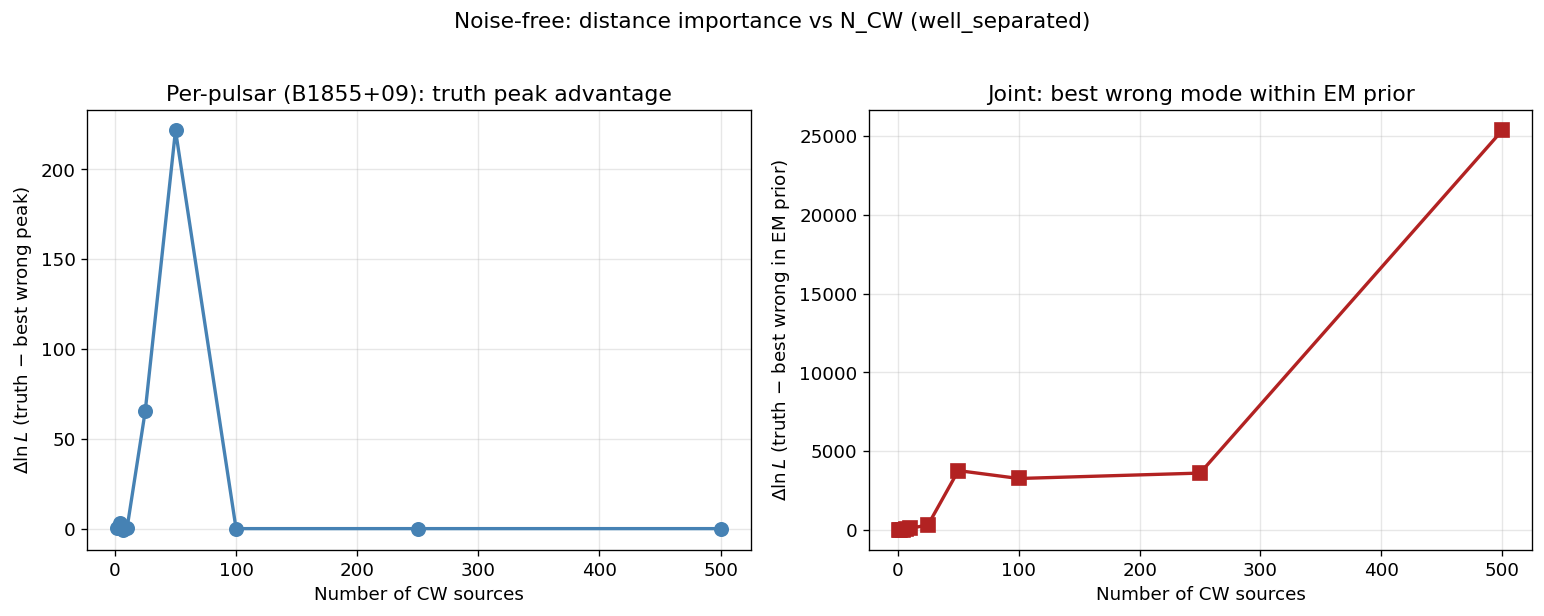

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Per-pulsar best wrong peak
ax = axes[0]
per_psr_delta = [multi_cw_results[n]["analysis"]["delta_lnL_truth_vs_best_wrong"]
                 for n in ncw_values]
ax.plot(ncw_values, per_psr_delta, "o-", color="steelblue", lw=2, ms=8)
ax.set_xlabel("Number of CW sources")
ax.set_ylabel(r"$\Delta \ln L$ (truth $-$ best wrong peak)")
ax.set_title(f"Per-pulsar ({test_psr_name}): truth peak advantage")
ax.grid(True, alpha=0.3)

# Joint shift
ax = axes[1]
joint_delta = [multi_cw_results[n]["delta_joint"] for n in ncw_values]
ax.plot(ncw_values, joint_delta, "s-", color="firebrick", lw=2, ms=8)
ax.set_xlabel("Number of CW sources")
ax.set_ylabel(r"$\Delta \ln L$ (truth $-$ best wrong in EM prior)")
ax.set_title("Joint: best wrong mode within EM prior")
ax.grid(True, alpha=0.3)

fig.suptitle(f"Noise-free: distance importance vs N_CW ({scenario})", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


## 4. Scenario comparison (noise-free)

Repeat the multi-CW analysis for all three scenarios: close in frequency,
close in sky position, and well-separated.


In [11]:
all_scenarios = ["close_freq", "close_sky", "well_separated"]
scenario_labels = {
    "close_freq": "Close in frequency",
    "close_sky": "Close in sky position",
    "well_separated": "Well-separated",
}

scenario_results = {}

for scenario in all_scenarios:
    print(f"\n{'='*50}")
    print(f"Scenario: {scenario_labels[scenario]}")
    print(f"{'='*50}")

    for ncw in ncw_values:
        rng_local = np.random.default_rng(42)
        cw_params = make_cw_params(ncw, rng_local, scenario=scenario)

        rmap, _ = inject_noisefree_cw(disco_psrs, cw_params)
        logl_fn, pkeys, bvals = build_noisefree_likelihood(disco_psrs, rmap, ncw, cw_params)

        ll_truth = float(logl_fn(bvals))

        # Per-pulsar scan
        dkey = f"{test_psr_name}_cw_p_dist"
        true_d = test_psr.pdist[0]
        all_dL = [compute_mode_spacing(cp["cos_gwtheta"], cp["gwphi"],
                                       cp["log10_fgw"], test_psr.pos) for cp in cw_params]
        min_dL = min(all_dL)
        max_dL = max(all_dL)
        scan_half = 10 * max_dL
        scan_d, scan_ll = scan_pulsar_distance(
            logl_fn, bvals, pkeys, dkey,
            max(0.01, true_d - scan_half), true_d + scan_half, n_points=5000,
        )
        analysis = analyze_peaks(scan_d, scan_ll, true_d, mode_spacing=min_dL)

        # Joint: best wrong mode within EM prior
        joint = compute_joint_best_wrong_in_prior(
            logl_fn, bvals, pkeys,
            disco_psrs, disco_psrs, cw_params, n_sigma=3.0,
        )

        key = (scenario, ncw)
        scenario_results[key] = {
            "per_psr_delta": analysis["delta_lnL_truth_vs_best_wrong"],
            "joint_delta": joint["delta_lnL"],
            "n_peaks": analysis["n_peaks"],
        }

        print(f"  N_CW={ncw:2d}: per-psr Δ={analysis['delta_lnL_truth_vs_best_wrong']:.4f}, "
              f"joint Δ={joint['delta_lnL']:.4f}")

        jax.clear_caches()

print("\nAll scenarios complete!")



Scenario: Close in frequency
  N_CW= 1: per-psr Δ=nan, joint Δ=0.0104
  N_CW= 2: per-psr Δ=0.3145, joint Δ=5.6166
  N_CW= 4: per-psr Δ=1.6533, joint Δ=12.4788
  N_CW= 7: per-psr Δ=-0.0811, joint Δ=72.6402
  N_CW=10: per-psr Δ=-0.2779, joint Δ=138.9772
  N_CW=25: per-psr Δ=21.7315, joint Δ=381.4401
  N_CW=50: per-psr Δ=13.8548, joint Δ=1245.9628
  N_CW=100: per-psr Δ=87.3656, joint Δ=1546.6243
  N_CW=250: per-psr Δ=103.4644, joint Δ=15785.8570
  N_CW=500: per-psr Δ=223.4833, joint Δ=7799.3353

Scenario: Close in sky position
  N_CW= 1: per-psr Δ=nan, joint Δ=0.0063
  N_CW= 2: per-psr Δ=nan, joint Δ=0.3869
  N_CW= 4: per-psr Δ=0.0020, joint Δ=5.4292
  N_CW= 7: per-psr Δ=0.0767, joint Δ=19.8922
  N_CW=10: per-psr Δ=0.2580, joint Δ=37.7174
  N_CW=25: per-psr Δ=6.4563, joint Δ=252.3241
  N_CW=50: per-psr Δ=11.1975, joint Δ=1096.1017
  N_CW=100: per-psr Δ=32.5035, joint Δ=2294.1500
  N_CW=250: per-psr Δ=68.8869, joint Δ=5488.0471
  N_CW=500: per-psr Δ=192.4434, joint Δ=7490.2699

Scenario: 

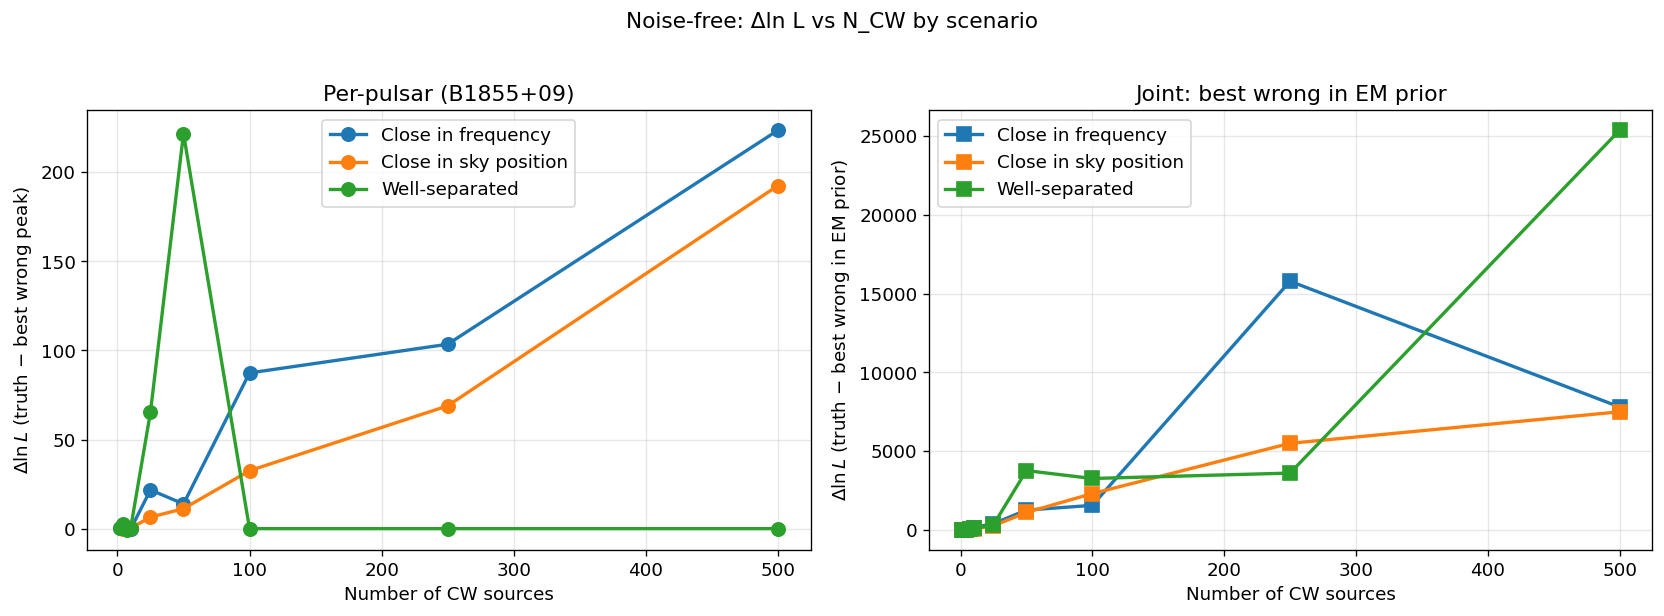

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-pulsar
ax = axes[0]
for scenario in all_scenarios:
    deltas = [scenario_results[(scenario, n)]["per_psr_delta"] for n in ncw_values]
    ax.plot(ncw_values, deltas, "o-", label=scenario_labels[scenario], lw=2, ms=8)
ax.set_xlabel("Number of CW sources")
ax.set_ylabel(r"$\Delta \ln L$ (truth $-$ best wrong peak)")
ax.set_title(f"Per-pulsar ({test_psr_name})")
ax.legend()
ax.grid(True, alpha=0.3)

# Joint
ax = axes[1]
for scenario in all_scenarios:
    deltas = [scenario_results[(scenario, n)]["joint_delta"] for n in ncw_values]
    ax.plot(ncw_values, deltas, "s-", label=scenario_labels[scenario], lw=2, ms=8)
ax.set_xlabel("Number of CW sources")
ax.set_ylabel(r"$\Delta \ln L$ (truth $-$ best wrong in EM prior)")
ax.set_title("Joint: best wrong in EM prior")
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle("Noise-free: Δln L vs N_CW by scenario", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


## 5. Summary


In [13]:
print("=" * 80)
print("NOISE-FREE SUMMARY")
print("=" * 80)

print(f"\n{'Scenario':25s} | " + " | ".join(f"N_CW={n}" for n in ncw_values))
print("-" * (25 + 3 + len(ncw_values) * 14))

print("\nPer-pulsar Delta ln L (truth peak - best wrong peak):")
for scenario in all_scenarios:
    row = f"{scenario_labels[scenario]:25s} | "
    for ncw in ncw_values:
        d = scenario_results[(scenario, ncw)]["per_psr_delta"]
        row += f" {d:10.4f}   | "
    print(row)

print(f"\nJoint Delta ln L (truth vs best wrong mode within EM prior):")
for scenario in all_scenarios:
    row = f"{scenario_labels[scenario]:25s} | "
    for ncw in ncw_values:
        d = scenario_results[(scenario, ncw)]["joint_delta"]
        row += f" {d:10.4f}   | "
    print(row)


NOISE-FREE SUMMARY

Scenario                  | N_CW=1 | N_CW=2 | N_CW=4 | N_CW=7 | N_CW=10 | N_CW=25 | N_CW=50 | N_CW=100 | N_CW=250 | N_CW=500
------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Per-pulsar Delta ln L (truth peak - best wrong peak):
Close in frequency        |         nan   |      0.3145   |      1.6533   |     -0.0811   |     -0.2779   |     21.7315   |     13.8548   |     87.3656   |    103.4644   |    223.4833   | 
Close in sky position     |         nan   |         nan   |      0.0020   |      0.0767   |      0.2580   |      6.4563   |     11.1975   |     32.5035   |     68.8869   |    192.4434   | 
Well-separated            |         nan   |      0.0894   |      2.8724   |     -0.5996   |      0.3129   |     65.3935   |    221.6959   |      0.0000   |      0.0000   |      0.0000   | 

Joint Delta ln L (truth vs best wrong mode within EM prior):
Cl

## Interpretation

**Noise-free results isolate the pure geometric/phase effect:**

1. **Single CW (N_CW=1):** The truth peak and all wrong-mode peaks should have
   essentially the same likelihood. This confirms that for a single source,
   the pulsar distance is uninformative — each mode is a valid phase assignment.

2. **Multiple CWs:** The truth peak should progressively dominate as N_CW grows.
   Each additional CW source imposes an additional phase constraint that only
   the true distance can satisfy simultaneously.

3. **Scenario comparison:** If the effect is similar across scenarios (close freq,
   close sky, well-separated), the distance constraint is a generic multi-source
   effect, not specific to "confused" sources.

The noise-free case provides the cleanest test because:
- No noise scatter to confuse peak heights
- No red noise GP degrees of freedom to absorb signal
- The only thing that matters is the CW phase matching


## 6. Diagnostic: timing model GP as likelihood peak culprit

**Background (from `01b_mode_breaking_1D`):**
- Noise-free CW injection → 1D scan over B1953+29 peaks ~0.28 dL away from truth (ΔlnL ≈ −4.8 for 1 CW).
- Red noise GP and GWB GP ruled out: same offset whether or not they are included.
- Remaining suspects: timing model GP or a deeper signal-model mismatch.

**This test:** compare three likelihoods on the same injection (CW_A params, same as mode-breaking analysis):

| Likelihood | Timing GP | Red noise | GWB |
|---|---|---|---|
| `build_noisefree_likelihood` (original) | ✓ | ✓ (log₁₀A=−20) | ✓ (log₁₀A=−20) |
| `build_pure_cw_notiming_likelihood` (new) | ✗ | ✗ | ✗ |

If removing the timing GP makes the peak land exactly at truth (ΔlnL ≈ 0), the timing model is absorbing part of the CW signal and shifting the peak.

If the no-timing likelihood is *still* offset from truth, the mismatch is deeper (CW waveform asymmetry, phase convention, or distance convention).

In [ ]:
import time

def build_pure_cw_notiming_likelihood(disco_psrs, residual_map, cw_params_list,
                                       log10_equad=-8.0):
    """White noise + CW only. No timing model, no red noise, no GWB.

    psl.N = NoiseMatrix1D_novar  (diagonal white noise, all constant)
    psl.y = CompoundDelay        (callable: residuals - CW_delay(params))
    NoiseMatrix1D_novar.make_kernelproduct(callable_y) uses jnp.sum => JIT-safe.

    The returned logL is a pure chi^2:
        logl = -0.5 * sum((residuals - CW(params))^2 / sigma^2) - const
    which peaks exactly at truth for a noise-free injection.
    """
    num_cw = len(cw_params_list)

    noisedict = {}
    for psr in disco_psrs:
        noisedict[psr.name + "_KAT_MKBF_efac"] = 1.0
        noisedict[psr.name + "_KAT_MKBF_log10_ecorr"] = -8.0
        noisedict[psr.name + "_KAT_MKBF_log10_t2equad"] = log10_equad

    pulsar_likes = [
        ds.PulsarLikelihood([
            np.array(residual_map[psr.name], copy=True),
            ds.makenoise_measurement(psr, noisedict=noisedict),
            MultiSourceDelay(psr, num_cw, include_pterm=True),
        ])
        for psr in disco_psrs
    ]

    # psl.N = NoiseMatrix1D_novar (no timing GP wrapping => no WoodburyKernel)
    # psl.y = CompoundDelay (callable)
    # NoiseMatrix1D_novar.make_kernelproduct(callable) uses jnp.sum => JIT-safe.
    kp_fns = [psl.N.make_kernelproduct(psl.y) for psl in pulsar_likes]
    all_params = sorted(set.union(*[set(kp.params) for kp in kp_fns]))

    disco_suffixes = ["" if i == 0 else f"_{i+1}" for i in range(num_cw)]
    param_dict = {}
    for suffix, cw_p in zip(disco_suffixes, cw_params_list):
        for key in MultiSourceDelay.global_params:
            param_dict[f"cw_{key}{suffix}"] = cw_p[key]
    for psr in disco_psrs:
        param_dict[f"{psr.name}_cw_p_dist"] = psr.pdist[0]

    order_map = {k: i for i, k in enumerate(all_params)}
    sorted_items = sorted(
        param_dict.items(), key=lambda kv: order_map.get(kv[0], float("inf"))
    )
    sorted_dict = {k: v for k, v in sorted_items if k in all_params}
    param_keys = list(sorted_dict.keys())
    base_vals = jnp.array([sorted_dict[k] for k in param_keys], dtype=jnp.float64)

    def logl_wrapped(x_array):
        params = {k: v for k, v in zip(param_keys, x_array)}
        return sum(kp(params) for kp in kp_fns)

    return jax.jit(logl_wrapped), param_keys, base_vals


# ── Injection: same CW_A params used in the mode-breaking analysis ─────────
CW_DIAG = [{
    "cos_gwtheta": 0.3,
    "gwphi": 2.5,
    "cos_inc": -0.2,
    "log10_mc": 9.0,
    "log10_fgw": -8.0,
    "log10_h": -12.0,
    "phase0": 1.0,
    "psi": 0.7,
}]

print("Injecting noise-free CW (CW_DIAG = CW_A from mode-breaking analysis)...")
rmap_diag, _ = inject_noisefree_cw(disco_psrs, CW_DIAG)

print("Building original likelihood (with timing GP, negligible RN+GWB)...")
t0 = time.time()
logl_orig, pkeys_orig, bvals_orig = build_noisefree_likelihood(
    disco_psrs, rmap_diag, 1, CW_DIAG
)
_ = logl_orig(bvals_orig)
print(f"  lnL(truth) = {float(logl_orig(bvals_orig)):.4f}  [{time.time()-t0:.0f} s]")

print("Building no-timing likelihood (white noise + CW only)...")
t0 = time.time()
logl_notm, pkeys_notm, bvals_notm = build_pure_cw_notiming_likelihood(
    disco_psrs, rmap_diag, CW_DIAG
)
_ = logl_notm(bvals_notm)
print(f"  lnL(truth) = {float(logl_notm(bvals_notm)):.4f}  [{time.time()-t0:.0f} s]")
print(f"  params ({len(pkeys_notm)}): {pkeys_notm}")


In [ ]:
# ── B1953+29 target ─────────────────────────────────────────────────────────
target_psr = next(p for p in disco_psrs if p.name == "B1953+29")
mu, sig = target_psr.pdist
scan_min = max(0.01, mu - 3.0 * sig)
scan_max = mu + 3.0 * sig
N_SCAN = 2000
dist_key = f"{target_psr.name}_cw_p_dist"

dL = compute_mode_spacing(
    CW_DIAG[0]["cos_gwtheta"], CW_DIAG[0]["gwphi"],
    CW_DIAG[0]["log10_fgw"], target_psr.pos
)
print(f"B1953+29:  mu={mu:.4f} kpc   sigma={sig:.4f} kpc   dL={dL:.6f} kpc")
print(f"Scan range: [{scan_min:.3f}, {scan_max:.3f}] kpc   N={N_SCAN}")

print("\nScanning original likelihood (with timing GP)...")
t0 = time.time()
sd_orig, sl_orig = scan_pulsar_distance(
    logl_orig, bvals_orig, pkeys_orig, dist_key, scan_min, scan_max, N_SCAN
)
print(f"  done in {time.time()-t0:.1f} s")

print("Scanning no-timing likelihood...")
t0 = time.time()
sd_notm, sl_notm = scan_pulsar_distance(
    logl_notm, bvals_notm, pkeys_notm, dist_key, scan_min, scan_max, N_SCAN
)
print(f"  done in {time.time()-t0:.1f} s")

def _summarise(label, scan_d, scan_ll, mu, dL):
    ll_truth = float(np.interp(mu, scan_d, scan_ll))
    ll_max   = float(np.max(scan_ll))
    d_max    = float(scan_d[np.argmax(scan_ll)])
    delta    = ll_truth - ll_max
    offset   = (d_max - mu) / dL
    print(f"  {label}")
    print(f"    lnL(truth) = {ll_truth:.4f}   lnL(grid max) = {ll_max:.4f}")
    print(f"    ΔlnL(truth - max) = {delta:.4f}")
    print(f"    grid max at {d_max:.6f} kpc  (offset = {offset:+.3f} dL)")
    return delta, offset

print()
print("=" * 60)
print("RESULTS: B1953+29 distance scan")
print("=" * 60)
delta_orig, off_orig = _summarise("original (with timing GP)", sd_orig, sl_orig, mu, dL)
delta_notm, off_notm = _summarise("no-timing  (pure chi^2)  ", sd_notm, sl_notm, mu, dL)
print()
if abs(delta_notm) < 0.5 and abs(delta_orig) > 1.0:
    print("VERDICT: timing model GP shifts the peak. Fix: investigate variance=1e-14.")
elif abs(delta_notm) < 0.5 and abs(delta_orig) < 0.5:
    print("VERDICT: both peak at truth. Timing model is NOT the culprit.")
elif abs(delta_notm) > 1.0 and abs(delta_orig) > 1.0:
    print("VERDICT: BOTH offset — deeper signal-model mismatch (CW phase convention, etc.)")
else:
    print("VERDICT: ambiguous. Inspect plots.")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Timing-model diagnostic: B1953+29  (mu={mu:.4f} kpc, dL={dL:.5f} kpc)",
    fontsize=12,
)
clip_lo = -50.0

for ax, (label, sd, sl) in zip(axes, [
    ("original\n(white noise + timing GP + CW)", sd_orig, sl_orig),
    ("no-timing\n(white noise + CW only)",       sd_notm, sl_notm),
]):
    sl_norm = sl - np.max(sl)
    ax.plot(sd, np.clip(sl_norm, clip_lo, 0), "C0", lw=0.7, alpha=0.9)
    ax.axvspan(max(0.01, mu - 3*sig), mu + 3*sig, alpha=0.06, color="gray")
    ax.axvspan(max(0.01, mu - sig),   mu + sig,   alpha=0.08, color="gray")
    ax.axvline(mu, color="red", lw=1.8, ls="--", label=f"truth = {mu:.4f} kpc")

    ll_norm_at_truth = float(np.interp(mu, sd, sl_norm))
    ax.plot(mu, np.clip(ll_norm_at_truth, clip_lo, 0), "r*", ms=12, zorder=5)

    d_max = float(sd[np.argmax(sl)])
    if abs(d_max - mu) > 0.1 * dL:
        ax.axvline(d_max, color="orange", lw=1.2, ls=":", label=f"grid max = {d_max:.4f}")

    delta = float(np.interp(mu, sd, sl_norm))
    ax.text(0.97, 0.97,
            f"ΔlnL(truth−max) = {delta:+.3f}\n"
            f"grid max at {d_max:.5f} kpc\n"
            f"offset = {(d_max-mu)/dL:+.3f} dL",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=9, family="monospace",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))

    ax.set_xlabel("Distance (kpc)", fontsize=11)
    ax.set_ylabel("Δ ln L  (max = 0)", fontsize=11)
    ax.set_title(label, fontsize=11)
    ax.set_ylim(clip_lo * 1.05, 2.0)
    ax.legend(fontsize=9, loc="lower left")
    ax.grid(True, alpha=0.25, lw=0.5)

plt.tight_layout()
plt.savefig("06_timing_diagnostic.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 06_timing_diagnostic.pdf")


In [ ]:
# ── What timing-related params does the original likelihood have? ──────────
print("Timing-related params in original likelihood (logl_orig.params):")
noisedict_tmp = {}
for psr in disco_psrs:
    noisedict_tmp[psr.name + "_KAT_MKBF_efac"] = 1.0
    noisedict_tmp[psr.name + "_KAT_MKBF_log10_ecorr"] = -8.0
    noisedict_tmp[psr.name + "_KAT_MKBF_log10_t2equad"] = -8.0
noise_tmp  = {p.name: ds.makenoise_measurement(p, noisedict=noisedict_tmp) for p in disco_psrs}
timing_tmp = {p.name: ds.makegp_timing(p, variance=1e-14) for p in disco_psrs}
T = ds.getspan(disco_psrs)
cgp_tmp    = ds.makecommongp_fourier(disco_psrs, ds.powerlaw, 30, T, name="rednoise")
ggp_tmp    = ds.makeglobalgp_fourier(disco_psrs, ds.powerlaw, ds.hd_orf, 30, T, name="gwb")
plikes_tmp = [
    ds.PulsarLikelihood([
        np.zeros(len(p.toas)),
        noise_tmp[p.name],
        timing_tmp[p.name],
        MultiSourceDelay(p, 1, include_pterm=True),
    ])
    for p in disco_psrs
]
fml_tmp  = ds.ArrayLikelihood(plikes_tmp, commongp=cgp_tmp, globalgp=ggp_tmp)
logl_tmp = fml_tmp.logL

timing_params = [k for k in logl_tmp.params if "timing" in k.lower()]
print(f"  Found {len(timing_params)} timing params:")
if timing_params:
    for k in timing_params:
        print(f"    {k}")
else:
    print("  NONE — timing model is fully marginalized (no free params).")
    print()
    print("  This means the timing model contribution is ONLY via the log-det term,")
    print("  which is CONSTANT w.r.t. pulsar distance.")
    print("  => Timing model CANNOT shift the peak analytically.")
    print()
    print("  If the no-timing scan above still shows an offset,")
    print("  the root cause is in the CW waveform or distance parametrisation.")

print()
print(f"All {len(logl_tmp.params)} params in original likelihood:")
for k in logl_tmp.params:
    print(f"  {k}")
